wokflow

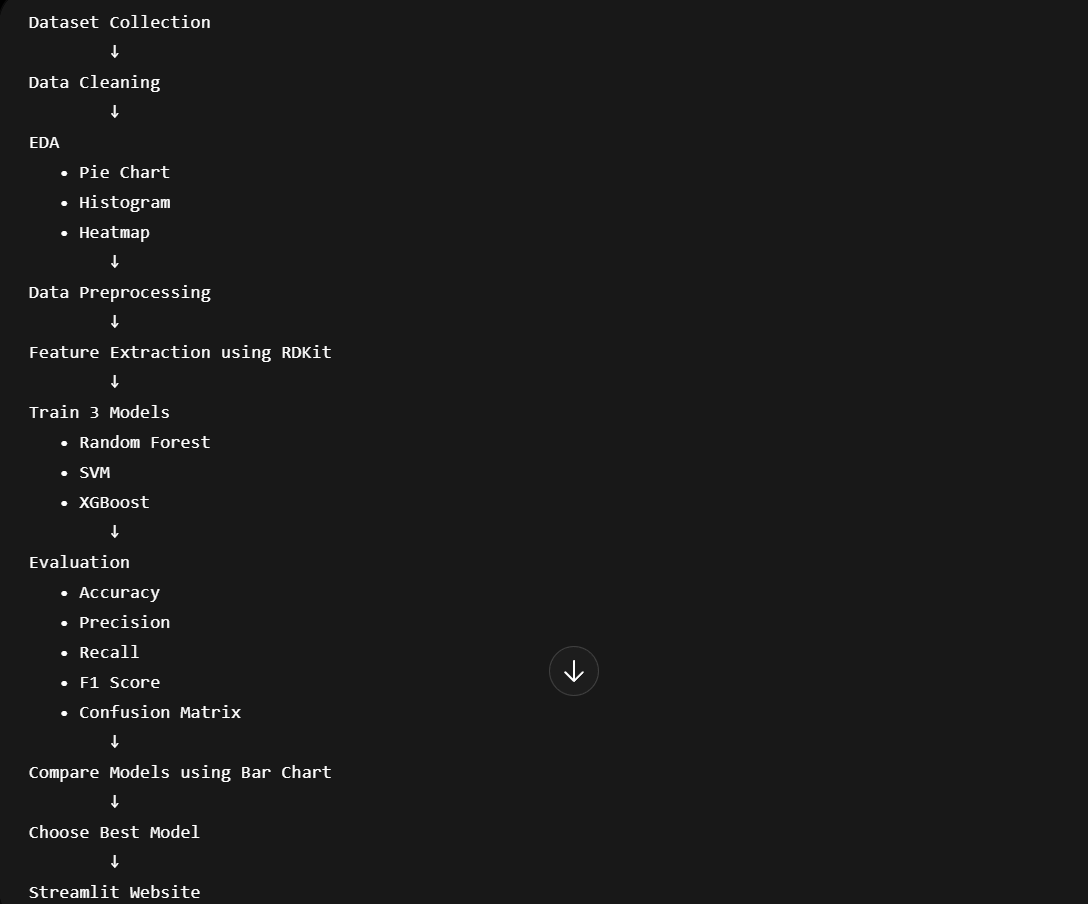

In [62]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# RDKit
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    mean_squared_error
)

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.preprocessing import LabelEncoder, StandardScaler
# Label Encoding and scaling

LoadDataset

In [63]:
df = pd.read_csv("curated-solubility-dataset.csv")

1.Data Cleaning

In [64]:
#Remove missing values
df = df.dropna()

In [65]:
#Remove Duplicate rows
df = df.drop_duplicates()

In [66]:
#keep important columns
df = df[['SMILES',
         'Solubility',
         'MolWt',
         'MolLogP',
         'TPSA',
         'NumHAcceptors',
         'NumHDonors']]

In [67]:
#convert solubility to categorical classes
def classify_solubility(value):

    if value > 0:
        return "High"

    elif value > -2:
        return "Medium"

    else:
        return "Low"

df['Class'] = df['Solubility'].apply(classify_solubility)

2. EDA (Exploratory Data Analysis)

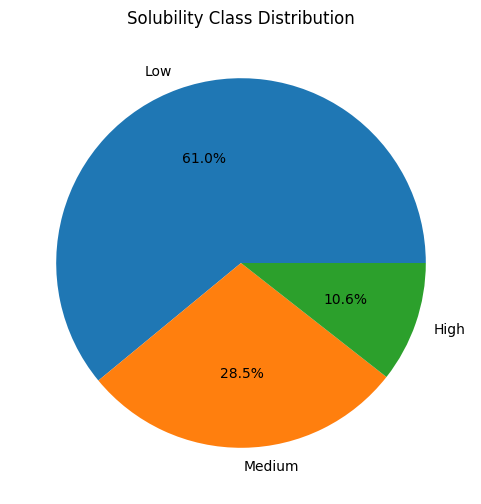

In [68]:
#pie chart of class distribution
class_counts = df['Class'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(class_counts,
        labels=class_counts.index,
        autopct='%1.1f%%')

plt.title("Solubility Class Distribution")

plt.show()

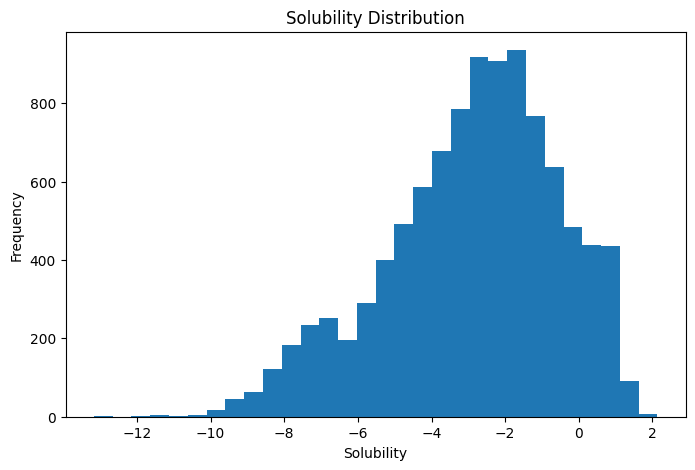

In [69]:
#histogram of solubility values
plt.figure(figsize=(8,5))

plt.hist(df['Solubility'], bins=30)

plt.title("Solubility Distribution")
plt.xlabel("Solubility")
plt.ylabel("Frequency")

plt.show()

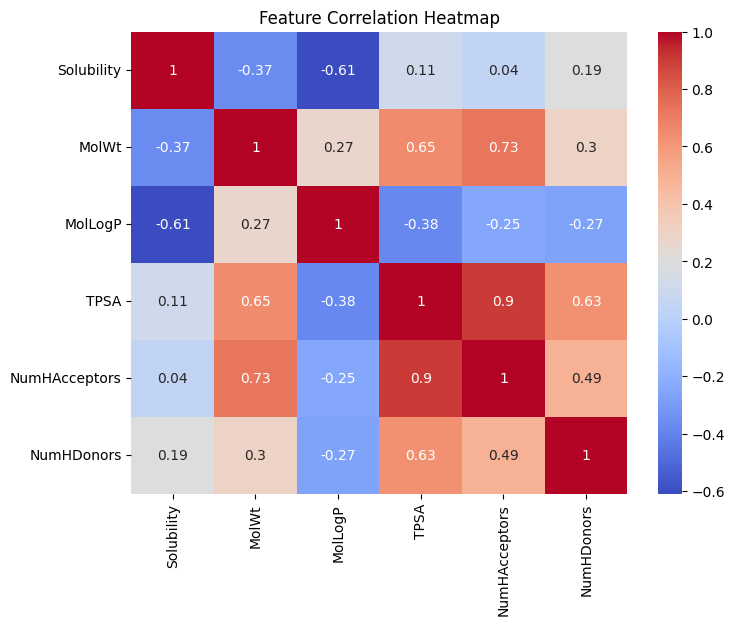

In [70]:
#correlation heatmap of features
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Solubility',
        'MolWt',
        'MolLogP',
        'TPSA',
        'NumHAcceptors',
        'NumHDonors']].corr(),

    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

Feature Extraction using RDKit

In [71]:
from rdkit import Chem
from rdkit.Chem import Descriptors

def extract_features(smiles, radius=2, n_bits=256):
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        return None
    
    try:
        Chem.SanitizeMol(mol)
    except:
        return None
    
    features = {
        'MolWt': Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'TPSA': Descriptors.TPSA(mol),
        'HAcceptors': Descriptors.NumHAcceptors(mol),
        'HDonors': Descriptors.NumHDonors(mol)
    }

    fp = GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    for i, bit in enumerate(fp):
        features[f'FP_{i}'] = int(bit)

    return features


In [72]:
features = df['SMILES'].apply(extract_features)

mask = features.notna()

feature_df = pd.DataFrame(features[mask].tolist()).reset_index(drop=True)
X = feature_df.copy()

y = df.loc[mask, 'Class'].reset_index(drop=True)


[01:24:38] DEPRECATION WARNING: please use MorganGenerator
[01:24:38] DEPRECATION WARNING: please use MorganGenerator
[01:24:38] DEPRECATION WARNING: please use MorganGenerator
[01:24:38] DEPRECATION WARNING: please use MorganGenerator
[01:24:38] DEPRECATION WARNING: please use MorganGenerator
[01:24:38] DEPRECATION WARNING: please use MorganGenerator
[01:24:38] DEPRECATION WARNING: please use MorganGenerator
[01:24:38] DEPRECATION WARNING: please use MorganGenerator
[01:24:38] DEPRECATION WARNING: please use MorganGenerator
[01:24:38] DEPRECATION WARNING: please use MorganGenerator
[01:24:38] DEPRECATION WARNING: please use MorganGenerator
[01:24:38] DEPRECATION WARNING: please use MorganGenerator
[01:24:38] DEPRECATION WARNING: please use MorganGenerator
[01:24:38] DEPRECATION WARNING: please use MorganGenerator
[01:24:38] DEPRECATION WARNING: please use MorganGenerator
[01:24:38] DEPRECATION WARNING: please use MorganGenerator
[01:24:38] DEPRECATION WARNING: please use MorganGenerat

Data preprocessing


In [73]:
#input features
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

#output labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)


In [74]:
#output labels are already created and encoded in the preprocessing step


In [75]:
# Label encoding was already performed in preprocessing
# y_encoded is already available

In [76]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

Tran 3 models

In [77]:
# Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [78]:
# SVM Classifier
svm_model = SVC(
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)


In [79]:
# XGBoost Classifier
xgb_model = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)


In [80]:
# Hyperparameter tuning for top models
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

xgb_param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
rf_search.fit(X_train, y_train)
best_rf_model = rf_search.best_estimator_

xgb_search = GridSearchCV(
    XGBClassifier(eval_metric='mlogloss', random_state=42),
    xgb_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train, y_train)
best_xgb_model = xgb_search.best_estimator_

print("Best RF params:", rf_search.best_params_)
print("Best XGB params:", xgb_search.best_params_)


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best RF params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best XGB params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 150, 'subsample': 0.8}


Model Evaluation Function

In [81]:
def evaluate_model(name, y_test, y_pred, y_score=None):

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )
    recall = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )
    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )
    mse = mean_squared_error(y_test, y_pred)
    roc_auc = None

    if y_score is not None:
        try:
            roc_auc = roc_auc_score(
                y_test,
                y_score,
                multi_class='ovr',
                average='weighted'
            )
        except Exception:
            roc_auc = None

    print(f"\n{name} Results")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("MSE:", mse)
    if roc_auc is not None:
        print("ROC-AUC:", roc_auc)

    return accuracy, precision, recall, f1, roc_auc, mse


Evaluate All models

In [82]:
rf_prob = rf_model.predict_proba(X_test)
svm_prob = svm_model.predict_proba(X_test)
xgb_prob = xgb_model.predict_proba(X_test)

rf_metrics = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

svm_metrics = evaluate_model(
    "SVM",
    y_test,
    svm_pred,
    svm_prob
)

xgb_metrics = evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)



Random Forest Results
Accuracy: 0.8181362725450901
Precision: 0.8131211861898207
Recall: 0.8181362725450901
F1 Score: 0.8124421030381673
MSE: 0.32615230460921846
ROC-AUC: 0.9343139688188434

SVM Results
Accuracy: 0.7645290581162325
Precision: 0.7527786499007018
Recall: 0.7645290581162325
F1 Score: 0.7531052580915959
MSE: 0.41432865731462926
ROC-AUC: 0.8985205063778378

XGBoost Results
Accuracy: 0.8321643286573146
Precision: 0.8307774808388905
Recall: 0.8321643286573146
F1 Score: 0.8310414158951631
MSE: 0.3166332665330661
ROC-AUC: 0.9343820357265248


In [83]:
# Evaluate tuned models
best_rf_pred = best_rf_model.predict(X_test)
best_rf_prob = best_rf_model.predict_proba(X_test)

best_xgb_pred = best_xgb_model.predict(X_test)
best_xgb_prob = best_xgb_model.predict_proba(X_test)

best_rf_metrics = evaluate_model(
    "Tuned Random Forest",
    y_test,
    best_rf_pred,
    best_rf_prob
)

best_xgb_metrics = evaluate_model(
    "Tuned XGBoost",
    y_test,
    best_xgb_pred,
    best_xgb_prob
)



Tuned Random Forest Results
Accuracy: 0.8206412825651302
Precision: 0.8161020586647085
Recall: 0.8206412825651302
F1 Score: 0.8150214651162161
MSE: 0.3221442885771543
ROC-AUC: 0.9344513752970209

Tuned XGBoost Results
Accuracy: 0.8351703406813628
Precision: 0.833175331021641
Recall: 0.8351703406813628
F1 Score: 0.8337484704730554
MSE: 0.3016032064128257
ROC-AUC: 0.9366221594642732


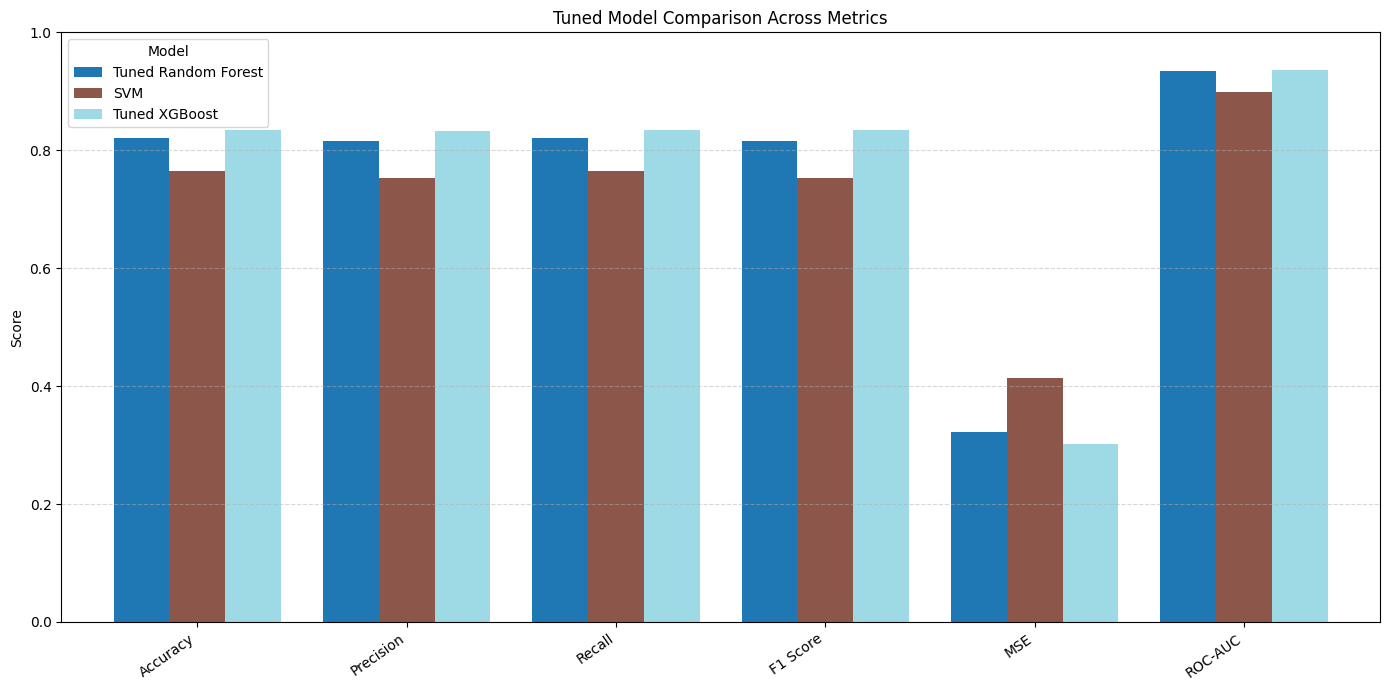

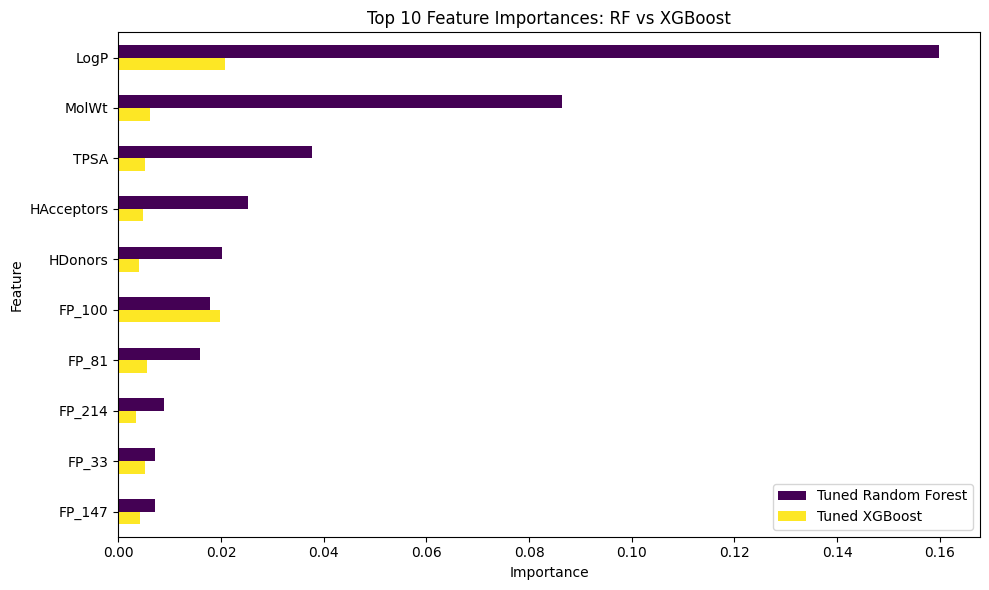

In [84]:
# Compare tuned Random Forest, SVM, and XGBoost across all metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'MSE', 'ROC-AUC']
rf_vals = [
    best_rf_metrics[0],
    best_rf_metrics[1],
    best_rf_metrics[2],
    best_rf_metrics[3],
    best_rf_metrics[5],
    best_rf_metrics[4]
]
svm_vals = [
    svm_metrics[0],
    svm_metrics[1],
    svm_metrics[2],
    svm_metrics[3],
    svm_metrics[5],
    svm_metrics[4]
]
xgb_vals = [
    best_xgb_metrics[0],
    best_xgb_metrics[1],
    best_xgb_metrics[2],
    best_xgb_metrics[3],
    best_xgb_metrics[5],
    best_xgb_metrics[4]
]

comparison_df = pd.DataFrame({
    'Tuned Random Forest': rf_vals,
    'SVM': svm_vals,
    'Tuned XGBoost': xgb_vals
}, index=metrics)

ax = comparison_df.plot(
    kind='bar',
    figsize=(14, 7),
    width=0.8,
    colormap='tab20'
)

plt.title('Tuned Model Comparison Across Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=35, ha='right')
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Show top feature importance from tuned Random Forest and XGBoost
rf_importances = pd.Series(best_rf_model.feature_importances_, index=X.columns)
xgb_importances = pd.Series(best_xgb_model.feature_importances_, index=X.columns)

importance_df = pd.DataFrame({
    'Tuned Random Forest': rf_importances,
    'Tuned XGBoost': xgb_importances
}).sort_values(by='Tuned Random Forest', ascending=False).head(10)

importance_df.plot(
    kind='barh',
    figsize=(10, 6),
    colormap='viridis'
)

plt.title('Top 10 Feature Importances: RF vs XGBoost')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


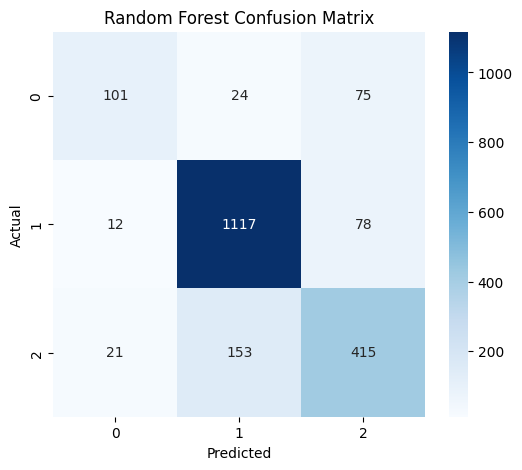

In [85]:
#Random Forest Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

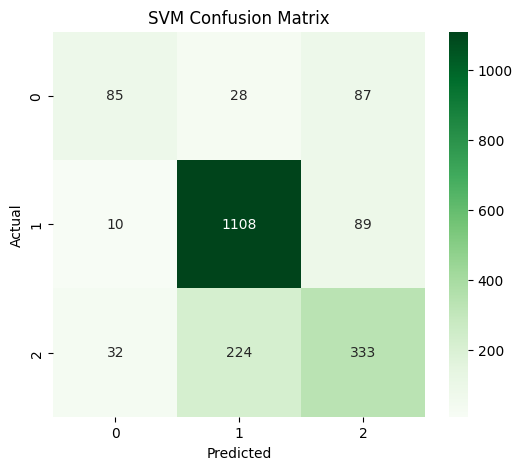

In [86]:
#Svm Confusion Matrix
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("SVM Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

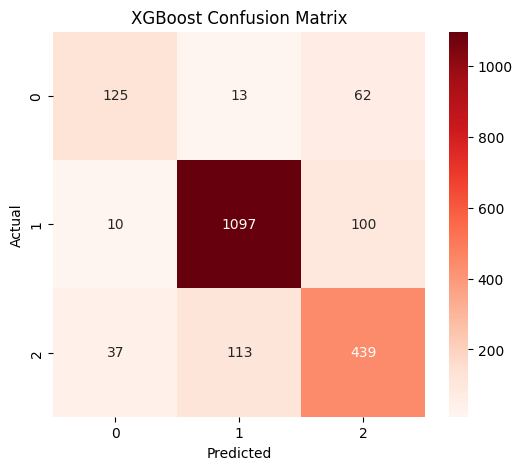

In [87]:
#XGBoost Confusion Matrix
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Reds')

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

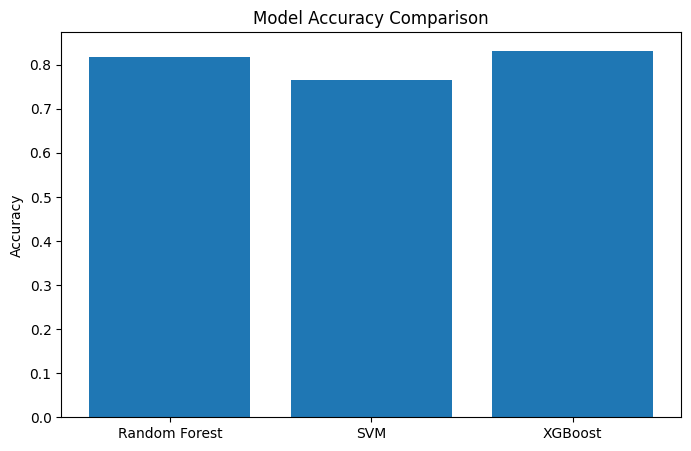

In [88]:
#Accuracy Comparison
models = ['Random Forest', 'SVM', 'XGBoost']

accuracies = [
    rf_metrics[0],
    svm_metrics[0],
    xgb_metrics[0]
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

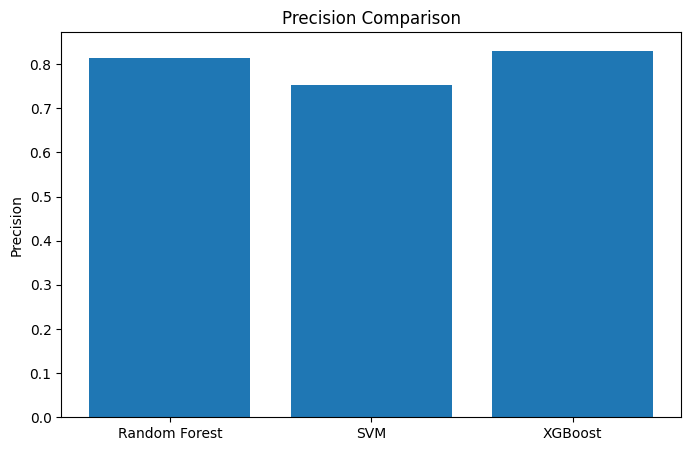

In [89]:
#Precision Comparison
precisions = [
    rf_metrics[1],
    svm_metrics[1],
    xgb_metrics[1]
]

plt.figure(figsize=(8,5))

plt.bar(models, precisions)

plt.title("Precision Comparison")
plt.ylabel("Precision")

plt.show()

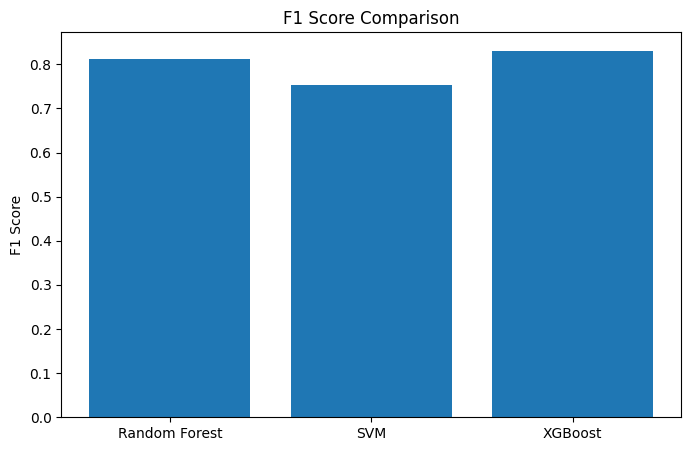

In [90]:
#F1 Score Comparison
f1_scores = [
    rf_metrics[3],
    svm_metrics[3],
    xgb_metrics[3]
]

plt.figure(figsize=(8,5))

plt.bar(models, f1_scores)

plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")

plt.show()

In [91]:
# Choose best model based on tuned accuracy
results = {
    'Tuned Random Forest': best_rf_metrics[0],
    'SVM': svm_metrics[0],
    'Tuned XGBoost': best_xgb_metrics[0]
}

best_model = max(results, key=results.get)
best_model_final = (
    best_xgb_model if best_model == 'Tuned XGBoost'
    else best_rf_model if best_model == 'Tuned Random Forest'
    else svm_model
)

print("Best Model:", best_model)
print("Best model accuracy:", results[best_model])


Best Model: Tuned XGBoost
Best model accuracy: 0.8351703406813628


In [92]:
import joblib

joblib.dump(best_model_final, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "label_encoder.pkl")

['label_encoder.pkl']